In [357]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress Prophet and PLS warnings

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{model_name} Performance:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    return {'mse': mse, 'mae': mae}

def fit_prophet_safely(df, periods=1):
    """Safely fit Prophet model with fallback to simple average"""
    try:
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
            mcmc_samples=0
        )
        model.fit(df)
        future = model.make_future_dataframe(periods=periods, freq='2W')
        forecast = model.predict(future)
        return forecast['yhat'].values[-periods:]
    except:
        # Fallback to moving average of last 5 points
        return [df['y'].tail(5).mean()] * periods

print("Loading synthetic data...")
df = pd.read_csv('synthetic_data_confirming.csv', parse_dates=['Time'])

# Prepare data matrices
print("\nPreparing data matrices...")
vocab = df['Topic'].unique()
clusters = df['Cluster'].unique()
dates = df['Time'].unique()
num_dates = len(dates)
test_size = 2  # Number of periods to predict (2 * 2W = 4 недели)

# Create word frequency matrix (dates × words)
word_matrix = pd.pivot_table(
    df,
    values='Count',
    index='Time',
    columns='Topic',
    aggfunc='sum'
).fillna(0)

# Create cluster matrix (dates × clusters)
cluster_matrix = pd.pivot_table(
    df,
    values='Count',
    index='Time',
    columns='Cluster',
    aggfunc='sum'
).fillna(0)

# Split data
X = word_matrix.values               # shape: (num_dates, num_words)
y = cluster_matrix.values            # shape: (num_dates, num_clusters)
X_train = X[:-test_size]             # all but last test_size rows
y_train = y[:-test_size]
X_test = X[-test_size:]
y_test = y[-test_size:]

# Scale features (StandardScaler(with_mean=False) чтобы не вычитать среднее из нулевых значений)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Loading synthetic data...

Preparing data matrices...


In [358]:
word_matrix

Topic,Music_core1,Music_core2,Music_core3,Music_core4,Music_noiseSD1,Music_noiseSD2,Music_noiseSD3,Music_noiseSD4,Music_noiseSD5,Music_noiseSD6,...,Tech_noiseSD7,Tech_noiseSD8,Tech_noiseWN1,Tech_noiseWN2,Tech_noiseWN3,Tech_noiseWN4,Tech_noiseWN5,Tech_noiseWN6,Tech_noiseWN7,Tech_noiseWN8
Time,,,,,,,,,,,,,,,,,,,,,
2024-01-07,219.925251,219.750744,220.328193,219.777920,22.191806,21.582285,16.502992,15.592469,9.254181,11.086699,...,9.475893,14.224420,5.739229,0.000000,10.816743,2.156964,11.605758,3.830550,8.955474,3.032632
2024-01-21,246.045238,244.298317,237.402910,227.952463,30.912433,29.624058,22.235561,26.836168,14.066028,5.573662,...,0.000000,29.202366,8.308912,10.370230,7.563166,4.913286,16.750085,11.802621,10.625421,5.931144
2024-02-04,246.734496,251.465553,252.147178,233.820794,13.750701,32.618106,14.521067,11.138891,6.601020,24.535509,...,10.424239,19.285191,5.261615,2.101634,1.122636,8.277705,0.000000,8.561340,0.000000,9.950590
2024-02-18,229.922917,242.075607,262.067718,240.720478,37.310024,42.534413,24.156926,21.930677,0.668612,10.223897,...,13.053693,15.470138,15.170306,5.880758,15.651865,5.038534,7.980195,0.000000,0.423651,0.000000
2024-03-03,230.191607,232.047694,266.673372,248.976006,20.909769,57.796655,21.748700,18.342079,4.928340,13.615837,...,16.233381,23.300853,1.264104,14.673324,0.000000,2.381685,2.208137,8.935405,0.385146,1.051301
2024-03-17,255.405776,238.451193,266.259484,255.799178,45.169216,85.759459,18.115908,21.611554,12.312142,9.718530,...,0.000000,43.414870,6.167645,10.381036,10.514925,4.342341,4.364310,6.168417,0.000000,3.177644
2024-03-31,282.327950,262.867058,263.133153,262.791507,73.151444,361.814698,24.527458,31.670811,7.666057,26.167894,...,5.825667,44.064611,0.545176,3.388816,11.003494,4.469822,20.866060,4.887747,9.976849,0.000000
2024-04-14,282.511557,287.909074,260.458685,270.683343,94.083948,195.407948,27.721456,28.761300,0.000000,27.683324,...,0.000000,56.710276,0.000000,0.000000,0.976279,2.779934,0.000000,2.668889,3.837043,0.084453
2024-04-28,265.877209,294.699619,260.762096,277.697520,362.238354,126.312420,35.474170,33.229776,10.502940,27.785575,...,0.000000,90.960109,1.329385,0.000000,13.354792,3.447224,6.522438,11.744676,3.412911,2.142675


In [359]:
cluster_matrix

Cluster,Music,Sports,Tech
Time,,,
2024-01-07,1038.257486,990.760937,1006.691521
2024-01-21,1152.727232,1068.703916,1117.319567
2024-02-04,1185.456965,1103.387537,1121.746716
2024-02-18,1171.805009,1104.753320,1123.994965
2024-03-03,1181.455021,1083.998076,1142.708973
2024-03-17,1252.903534,1106.497382,1194.267861
2024-03-31,1654.542833,1220.131628,1282.372472
2024-04-14,1515.237887,1254.526993,1285.572016
2024-04-28,1747.934625,1277.247551,1364.818580


In [ ]:
# =============================
# Hypothesis 1: Feature Selection
# =============================

print("\nTesting Hypothesis 1: Feature Selection")
results = []

def fit_pls_safely(X_tr, y_tr, X_te, n_components, return_model=False):
    """
    Fit PLS with numerical-stability fallbacks.
    Если возникает ошибка, уменьшаем n_components. В крайнем случае возвращаем среднее.
    """
    try:
        # Добавляем epsilon, чтобы избежать проблем с нулевыми столбцами
        eps = 1e-10
        X_tr_stable = X_tr + eps
        X_te_stable = X_te + eps

        pls = PLSRegression(n_components=n_components, scale=False)
        pls.fit(X_tr_stable, y_tr)
        if return_model:
            return pls.predict(X_te_stable), pls
        return pls.predict(X_te_stable)
    except:
        # Если не удалось, пробуем с уменьшенным числом компонент
        try:
            n_components_new = max(1, n_components - 1)
            print(f"Retrying PLS with {n_components_new} components...")
            pls = PLSRegression(n_components=n_components_new, scale=False)
            pls.fit(X_tr_stable, y_tr)
            if return_model:
                return pls.predict(X_te_stable), pls
            return pls.predict(X_te_stable)
        except:
            # Крайняя мера: среднее значение по y_train
            print("PLS fallback to mean prediction...")
            mean_pred = np.tile(np.mean(y_tr, axis=0), (X_te.shape[0], 1))
            if return_model:
                return mean_pred, None
            return mean_pred
        
n_components_BASE = 3
n_components = min(n_components_BASE, X_train_scaled.shape[1] - 1)
# Full model на всех признаках
y_pred_full, pls_model = fit_pls_safely(
    X_train_scaled, y_train, X_test_scaled, n_components, return_model=True
)
full_metrics = evaluate_model(y_test, y_pred_full, "Full Model (All Features)")
results.append({"method": "Full Model", **full_metrics})

# Функция для важности признаков по PLS: сумма абсолютных коэффициентов по всем таргетам
# coef_ может быть (n_features, n_targets) ИЛИ (n_targets, n_features)
coef_abs = np.abs(pls_model.coef_)

if coef_abs.shape[0] == X_train_scaled.shape[1]:          # (n_features, n_targets)
    importance = coef_abs.sum(axis=1)                     # → (n_features,)
else:                                                     # (n_targets, n_features)
    importance = coef_abs.sum(axis=0)                     # → (n_features,)


top_k = int(len(vocab) * 0.2)  # 20% от общего числа слов
selected_idx = np.argsort(importance)[::-1][:top_k]

# Выбранные слова (топ-20%)
selected_vocab = [vocab[i] for i in selected_idx]

# Тренируем PLS снова, но только на отобранных признаках
X_train_selected = X_train_scaled[:, selected_idx]
X_test_selected = X_test_scaled[:, selected_idx]
pls_selected = PLSRegression(n_components=min(n_components_BASE, X_train_selected.shape[1] - 1), scale=False)
pls_selected.fit(X_train_selected, y_train)
y_pred_selected = pls_selected.predict(X_test_selected)
selected_metrics = evaluate_model(y_test, y_pred_selected, "Selected Features Model")
results.append({"method": "Selected Features", **selected_metrics})



Testing Hypothesis 1: Feature Selection

Full Model (All Features) Performance:
MSE: 2720.7033
MAE: 43.5407

Selected Features Model Performance:
MSE: 63638.6447
MAE: 214.4504


In [361]:
y_pred_selected

array([[2345.433375  , 2669.94550446, 2496.31183969],
       [2255.8568262 , 2692.24031067, 2313.13965508]])

In [362]:
y_pred_full

array([[2100.47101173, 2156.61331008, 2162.99001799],
       [2143.92224551, 2255.12698081, 2110.3319212 ]])

In [363]:
y_test

array([[2154.55578266, 2161.22627183, 2130.33207428],
       [2149.56039629, 2195.04791629, 2110.78303629]])

In [364]:
importance.shape

(60,)

In [365]:
print(selected_idx)

[ 1 21 41 43  3 23 40  0 20 42  2 22]


In [366]:
len(vocab)

60

In [367]:
selected_vocab

['Sports_core2',
 'Music_core2',
 'Tech_core2',
 'Tech_core4',
 'Sports_core4',
 'Music_core4',
 'Tech_core1',
 'Sports_core1',
 'Music_core1',
 'Tech_core3',
 'Sports_core3',
 'Music_core3']

In [368]:
print(X_train_scaled.shape)

(38, 60)


In [369]:
print(X_train_selected.shape)

(38, 12)


In [370]:
word_predictions.shape

(2, 12)

In [371]:
word_predictions

array([[495.34884106, 494.49512296, 495.27319476, 491.52886394,
        494.47144436, 491.68816132, 519.36416284, 506.79042658,
        518.33382478, 507.87876148, 515.16546203, 506.57446994],
       [515.80892756, 515.14881103, 514.55477592, 501.75456387,
        501.18842212, 500.06732359, 541.56042666, 492.44114782,
        540.87739678, 492.92990988, 535.46607837, 492.14535838]])

In [372]:
cluster_from_words

array([[2016.03287168, 2007.92321625, 2012.95664811],
       [2050.80465635, 2042.82757137, 2050.31091427]])

In [373]:
cluster_from_words

array([[2016.03287168, 2007.92321625, 2012.95664811],
       [2050.80465635, 2042.82757137, 2050.31091427]])

## 95 интервал + 

In [374]:

# =============================
# Hypothesis 2: Individual Word Prediction (на отобранных словах)
# =============================
X_train_selected_orig   = X_train[:, selected_idx] 

print("\nTesting Hypothesis 2: Individual Word Prediction")

# --- Метод 1: Direct cluster prediction с Prophet ---
cluster_predictions = np.zeros((test_size, len(clusters)))
for i, cluster in enumerate(clusters):
    cluster_data = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': y_train[:, i]
    })
    cluster_predictions[:, i] = fit_prophet_safely(cluster_data, periods=test_size)

direct_metrics = evaluate_model(y_test, cluster_predictions, "Direct Cluster Prediction")
results.append({"method": "Direct Cluster", **direct_metrics})

# --- Метод 2: Individual word prediction и агрегация по отобранным словам ---
word_predictions = np.zeros((test_size, len(selected_vocab)))

# Используем X_train_selected_orig (отобранные слова) вместо полного X_train
for i, word in enumerate(selected_vocab):
    # Здесь X_train_selected_orig[:, i] соответствует столбцу выбранного слова
    word_data = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': X_train_selected_orig[:, i]
    })
    word_predictions[:, i] = fit_prophet_safely(word_data, periods=test_size)

# Агрегируем прогнозы отобранных слов по кластерам
cluster_from_words = np.zeros((test_size, len(clusters)))
for ci, cluster in enumerate(clusters):
    # Для текущего кластера находим индексы слов в selected_vocab, которые ему принадлежат
    word_indices = [
        idx_sel for idx_sel, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    if word_indices:                       # в кластере есть отобранные слова
        print(f"\nCluster: {cluster}")
        for idx_sel in word_indices:
            w = selected_vocab[idx_sel]
            preds = word_predictions[:, idx_sel]
            # preds — массив длиной test_size (у нас 2 периода вперёд)
            print(f"  {w:<25s}  t+1={preds[0]:.2f}   t+2={preds[1]:.2f}")
        # агрегируем
        cluster_from_words[:, ci] = word_predictions[:, word_indices].sum(axis=1)
    else:                                  # ни одного слова не попало
        print(f"\nCluster: {cluster}  —  no selected words")
        cluster_from_words[:, ci] = np.mean(y_train[:, ci])
        
    print(f"\n")
    print(f"  Word-based       t+1={cluster_from_words[0, ci]:.2f}   "
              f"t+2={cluster_from_words[1, ci]:.2f}")
    print(f"  Direct Prophet   t+1={cluster_predictions[0, ci]:.2f}   "
          f"t+2={cluster_predictions[1, ci]:.2f}")
    print(f"  True values       t+1={y_test[0, ci]:.2f}   t+2={y_test[1, ci]:.2f}")

word_based_metrics = evaluate_model(y_test, cluster_from_words, "Word-based Prediction (Selected Words)")
results.append({"method": "Word-based", **word_based_metrics})

# =============================
# Сохраняем результаты и строим график
# =============================

results_df = pd.DataFrame(results)
results_df.to_csv('hypothesis_test_results.csv', index=False)
print("\nResults saved to hypothesis_test_results.csv")

plt.figure(figsize=(12, 6))
plt.bar(results_df['method'], results_df['mse'])
plt.title('MSE Comparison Across Methods')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('hypothesis_comparison.png')
plt.close()
print("Results visualization saved to hypothesis_comparison.png")

# =============================
# Вывод ключевых показателей
# =============================

print("\nKey Findings:")
print("1. Feature Selection Impact:")
feature_improvement = (full_metrics['mse'] - selected_metrics['mse']) / full_metrics['mse'] * 100
print(f"   {'Improvement' if feature_improvement > 0 else 'Degradation'}: {abs(feature_improvement):.1f}%")

print("\n2. Word-level vs Direct Prediction:")
word_improvement = (direct_metrics['mse'] - word_based_metrics['mse']) / direct_metrics['mse'] * 100
print(f"   {'Improvement' if word_improvement > 0 else 'Degradation'}: {abs(word_improvement):.1f}%")


10:22:28 - cmdstanpy - INFO - Chain [1] start processing



Testing Hypothesis 2: Individual Word Prediction


10:22:28 - cmdstanpy - INFO - Chain [1] done processing


10:22:28 - cmdstanpy - INFO - Chain [1] start processing
10:22:28 - cmdstanpy - INFO - Chain [1] done processing
10:22:28 - cmdstanpy - INFO - Chain [1] start processing
10:22:28 - cmdstanpy - INFO - Chain [1] done processing
10:22:29 - cmdstanpy - INFO - Chain [1] start processing
10:22:29 - cmdstanpy - INFO - Chain [1] done processing
10:22:29 - cmdstanpy - INFO - Chain [1] start processing



Direct Cluster Prediction Performance:
MSE: 353471.1341
MAE: 586.7020


10:22:29 - cmdstanpy - INFO - Chain [1] done processing
10:22:29 - cmdstanpy - INFO - Chain [1] start processing
10:22:29 - cmdstanpy - INFO - Chain [1] done processing
10:22:29 - cmdstanpy - INFO - Chain [1] start processing
10:22:42 - cmdstanpy - INFO - Chain [1] done processing
10:22:43 - cmdstanpy - INFO - Chain [1] start processing
10:22:43 - cmdstanpy - INFO - Chain [1] done processing
10:22:43 - cmdstanpy - INFO - Chain [1] start processing
10:22:44 - cmdstanpy - INFO - Chain [1] start processing
10:22:44 - cmdstanpy - INFO - Chain [1] done processing
10:22:44 - cmdstanpy - INFO - Chain [1] start processing
10:22:44 - cmdstanpy - INFO - Chain [1] done processing
10:22:44 - cmdstanpy - INFO - Chain [1] start processing
10:22:44 - cmdstanpy - INFO - Chain [1] done processing
10:22:44 - cmdstanpy - INFO - Chain [1] start processing
10:22:44 - cmdstanpy - INFO - Chain [1] done processing
10:22:44 - cmdstanpy - INFO - Chain [1] start processing
10:22:44 - cmdstanpy - INFO - Chain [1]


Cluster: Sports
  Sports_core2               t+1=495.35   t+2=515.81
  Sports_core4               t+1=494.47   t+2=501.19
  Sports_core1               t+1=507.88   t+2=492.93
  Sports_core3               t+1=518.33   t+2=540.88


  Word-based       t+1=2016.03   t+2=2050.80
  Direct Prophet   t+1=2577.57   t+2=2696.56
  True values       t+1=2154.56   t+2=2149.56

Cluster: Music
  Music_core2                t+1=494.50   t+2=515.15
  Music_core4                t+1=472.17   t+2=472.17
  Music_core1                t+1=506.57   t+2=492.15
  Music_core3                t+1=515.17   t+2=535.47


  Word-based       t+1=1988.41   t+2=2014.93
  Direct Prophet   t+1=2778.96   t+2=2822.26
  True values       t+1=2161.23   t+2=2195.05

Cluster: Tech
  Tech_core2                 t+1=495.27   t+2=514.55
  Tech_core4                 t+1=491.53   t+2=501.75
  Tech_core1                 t+1=506.79   t+2=492.44
  Tech_core3                 t+1=519.36   t+2=541.56


  Word-based       t+1=2012.96   t+2=2

In [385]:
import matplotlib.dates as mdates

# 1) Для каждого кластера: строим прямой Prophet, чтобы получить DF с yhat, yhat_lower, yhat_upper
direct_intervals = {}   # direct_intervals[cluster] = DataFrame с колонками ds, yhat, yhat_lower, yhat_upper
for i, cluster in enumerate(clusters):
    # Готовим DataFrame для истории кластера
    history_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': y_train[:, i]
    })
    model = Prophet(yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    interval_width=0.95,
                    mcmc_samples=0)
    model.fit(history_cluster)
    future = model.make_future_dataframe(periods=test_size, freq='2W')
    forecast_df = model.predict(future)
    # Оставим только последние тестовые периоды вместе с их пределами
    direct_intervals[cluster] = forecast_df.loc[forecast_df['ds'].isin(dates[-test_size:]),
                                                 ['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)

# 2) Для каждого кластера: строим Word-based Prophet-интервалы
#    Алгоритм: для каждого отобранного слова w, строим свой Prophet, берём forecast_df с lower/upper.
#    Затем суммируем yhat, yhat_lower, yhat_upper по всем словам, принадлежащим кластеру.
word_intervals = {}  # word_intervals[cluster] = DataFrame с ds, yhat, yhat_lower, yhat_upper (суммарные)
for i, cluster in enumerate(clusters):
    # Находим список выбранных слов, относящихся к этому кластеру
    idxs = [j for j, w in enumerate(selected_vocab)
            if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster]
    if not idxs:
        continue

    # Список DataFrame-ов для каждого слова
    per_word_dfs = []
    for j in idxs:
        w = selected_vocab[j]
        history_word = pd.DataFrame({
            'ds': dates[:-test_size],
            'y': X_train_selected_orig[:, j]
        })
        m_word = Prophet(yearly_seasonality=True,
                         weekly_seasonality=False,
                         daily_seasonality=False,
                         interval_width=0.95,
                         mcmc_samples=0)
        m_word.fit(history_word)
        future_word = m_word.make_future_dataframe(periods=test_size, freq='2W')
        dfw = m_word.predict(future_word).loc[future_word['ds'].isin(dates[-test_size:]),
                                             ['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
        per_word_dfs.append(dfw)

    # Склеиваем: суммируем по индексам строк
    agg = per_word_dfs[0].copy()
    agg['yhat']       = per_word_dfs[0]['yhat']
    agg['yhat_lower'] = per_word_dfs[0]['yhat_lower']
    agg['yhat_upper'] = per_word_dfs[0]['yhat_upper']

    for dfw in per_word_dfs[1:]:
        agg['yhat']       += dfw['yhat']
        agg['yhat_lower'] += dfw['yhat_lower']   # приближение: складываем границы
        agg['yhat_upper'] += dfw['yhat_upper']

    word_intervals[cluster] = agg

# 3) Строим графики для каждого кластера
#    На одном рисунке: исторические точки (кластера),
#    прогноз Direct Prophet с интервалом,
#    прогноз Word-based с интервалом.

# Параметр: сколько последних точек истории оставить для показа
last_history = 6  # например, последние 6 точек (12 недель)

for i, cluster in enumerate(clusters):
    # Берём все даты для этого кластера
    dates_all = pd.to_datetime(dates)

    # Определяем границу, с какого момента показывать историю
    # берем последние last_history точек до тестовой части
    start_idx = -(test_size + last_history)
    # Если данных меньше, просто показываем с самого начала
    if abs(start_idx) > len(dates_all):
        start_idx = 0

    # Исторические даты и значения (обрезаем, чтобы лучше было видно)
    hist_dates = dates_all[start_idx: -test_size]
    hist_vals  = cluster_matrix[cluster].values[start_idx: -test_size]

    # Даты тестовой части (через две недели каждая)
    future_dates = dates_all[-test_size:]

    # Информация из direct_intervals и word_intervals
    df_dir_int = direct_intervals[cluster]         # содержит ['ds','yhat','yhat_lower','yhat_upper'] для тестовых дат
    df_word_int = word_intervals.get(cluster, None)  # возможен None, если не было отобранных слов

    # Истинные y_test для этого кластера
    true_vals = y_test[:, i]

    # --- Рисуем сам график ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1) История (обрезанная) чёрными точками
    ax.scatter(hist_dates, hist_vals,
               color='black', s=20, label='History (cluster)')

    # 2) True values (тестовые точки) — красные точки
    ax.scatter(future_dates, true_vals,
               color='red', s=40, marker='o', label='True (test)')

    # 3) Direct Prophet: линия + интервал
    if cluster in direct_intervals:
        # Линия прогноза
        ax.plot(df_dir_int['ds'], df_dir_int['yhat'],
                color='tab:orange', lw=2, label='Direct Prophet (mean)')
        # Доверительный интервал
        ax.fill_between(df_dir_int['ds'],
                        df_dir_int['yhat_lower'],
                        df_dir_int['yhat_upper'],
                        color='tab:orange', alpha=0.3)

    # 4) Word-based Prophet: линия + интервал (если есть данные)
    if df_word_int is not None:
        ax.plot(df_word_int['ds'], df_word_int['yhat'],
                color='tab:green', lw=2, label='Word-based (mean)')
        ax.fill_between(df_word_int['ds'],
                        df_word_int['yhat_lower'],
                        df_word_int['yhat_upper'],
                        color='tab:green', alpha=0.3)

    # 5) Настройки оформления
    ax.set_title(f"Cluster `{cluster}` Forecast (Direct vs Word-based)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

    # Форматирование оси X (даты)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    # Если хотим “подрезать” ось X так, чтобы не было слишком много пустого места:
    # вручную задаём пределы по оси X (с начала последнего историяного окна до конца прогноза)
    xmin = hist_dates.min()
    xmax = future_dates.max()
    ax.set_xlim(xmin, xmax + pd.Timedelta(days=1))

    plt.tight_layout()
    out_name = f"cluster_{cluster}_forecast_with_intervals.png"
    plt.savefig(out_name, dpi=150)
    plt.close()
    print(f"Saved plot → {out_name}")

11:13:19 - cmdstanpy - INFO - Chain [1] start processing


11:13:19 - cmdstanpy - INFO - Chain [1] done processing
11:13:19 - cmdstanpy - INFO - Chain [1] start processing
11:13:19 - cmdstanpy - INFO - Chain [1] done processing
11:13:19 - cmdstanpy - INFO - Chain [1] start processing
11:13:19 - cmdstanpy - INFO - Chain [1] done processing
11:13:19 - cmdstanpy - INFO - Chain [1] start processing
11:13:19 - cmdstanpy - INFO - Chain [1] done processing
11:13:19 - cmdstanpy - INFO - Chain [1] start processing
11:13:20 - cmdstanpy - INFO - Chain [1] done processing
11:13:20 - cmdstanpy - INFO - Chain [1] start processing
11:13:20 - cmdstanpy - INFO - Chain [1] done processing
11:13:20 - cmdstanpy - INFO - Chain [1] start processing
11:13:20 - cmdstanpy - INFO - Chain [1] done processing
11:13:20 - cmdstanpy - INFO - Chain [1] start processing
11:13:20 - cmdstanpy - INFO - Chain [1] done processing
11:13:20 - cmdstanpy - INFO - Chain [1] start processing
11:13:34 - cmdstanpy - INFO - Chain [1] done processing
11:13:34 - cmdstanpy - INFO - Chain [1] 

Saved plot → cluster_Sports_forecast_with_intervals.png
Saved plot → cluster_Music_forecast_with_intervals.png
Saved plot → cluster_Tech_forecast_with_intervals.png


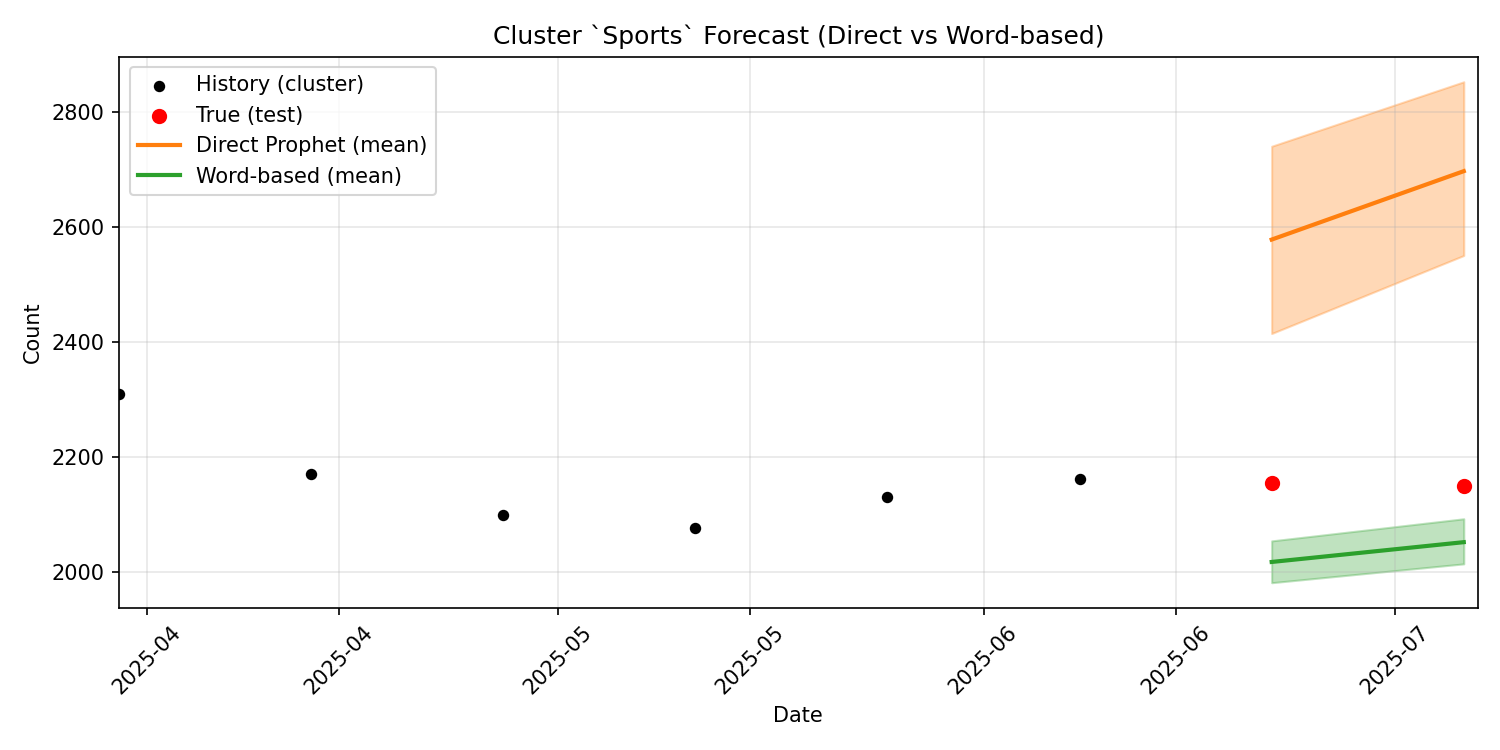

## исправленный блок H2, в котором у Prophet выставлен более широкий интервал (interval_width=0.999 вместо 0.95) и добавлен параметр changepoint_prior_scale=0.5 (по умолчанию 0.05) для большей гибкости при резких выбросах.



In [387]:
# 1) Для каждого кластера строим Direct Prophet
#    с interval_width=0.999 и changepoint_prior_scale=0.5
direct_intervals = {}   # будет хранить DataFrame(ds, yhat, yhat_lower, yhat_upper)
for i, cluster in enumerate(clusters):
    # Формируем DataFrame истории кластера
    history_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': y_train[:, i]
    })
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.999,               # расширенный доверительный интервал
        changepoint_prior_scale=0.5,       # более гибкие точки разлома
        mcmc_samples=0
    )
    model.fit(history_cluster)
    future = model.make_future_dataframe(periods=test_size, freq='2W')
    forecast_df = model.predict(future)

    # Сохраняем только последние тестовые периоды
    direct_intervals[cluster] = forecast_df.loc[
        forecast_df['ds'].isin(dates[-test_size:]),
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ].reset_index(drop=True)

# 2) Для каждого кластера строим Word-based Prophet-интервалы
#    (по каждому отобранному слову, а затем складываем границы,
#    но при этом у самого Prophet задан расширенный интервал и гибкость)
word_intervals = {}  # будет хранить DataFrame(ds, yhat, yhat_lower, yhat_upper)
for i, cluster in enumerate(clusters):
    # Список индексов отобранных слов для данного кластера
    idxs = [
        j for j, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    if not idxs:
        continue

    per_word_dfs = []
    for j in idxs:
        w = selected_vocab[j]
        history_word = pd.DataFrame({
            'ds': dates[:-test_size],
            'y': X_train_selected_orig[:, j]
        })
        m_word = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.999,           # расширенный доверительный интервал
            changepoint_prior_scale=0.5,   # более гибкие точки разлома
            mcmc_samples=0
        )
        m_word.fit(history_word)
        future_word = m_word.make_future_dataframe(periods=test_size, freq='2W')
        dfw = m_word.predict(future_word).loc[
            future_word['ds'].isin(dates[-test_size:]),
            ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
        ].reset_index(drop=True)
        per_word_dfs.append(dfw)

    # Склеиваем: суммируем прогнозы и границы по всем словам
    agg = per_word_dfs[0].copy()
    agg['yhat']       = per_word_dfs[0]['yhat']
    agg['yhat_lower'] = per_word_dfs[0]['yhat_lower']
    agg['yhat_upper'] = per_word_dfs[0]['yhat_upper']

    for dfw in per_word_dfs[1:]:
        agg['yhat']       += dfw['yhat']
        agg['yhat_lower'] += dfw['yhat_lower']
        agg['yhat_upper'] += dfw['yhat_upper']

    word_intervals[cluster] = agg
    
# 3) Строим графики для каждого кластера
#    На одном рисунке: исторические точки (кластера),
#    прогноз Direct Prophet с интервалом,
#    прогноз Word-based с интервалом.

# Параметр: сколько последних точек истории оставить для показа
last_history = 6  # например, последние 6 точек (12 недель)

for i, cluster in enumerate(clusters):
    # Берём все даты для этого кластера
    dates_all = pd.to_datetime(dates)

    # Определяем границу, с какого момента показывать историю
    # берем последние last_history точек до тестовой части
    start_idx = -(test_size + last_history)
    # Если данных меньше, просто показываем с самого начала
    if abs(start_idx) > len(dates_all):
        start_idx = 0

    # Исторические даты и значения (обрезаем, чтобы лучше было видно)
    hist_dates = dates_all[start_idx: -test_size]
    hist_vals  = cluster_matrix[cluster].values[start_idx: -test_size]

    # Даты тестовой части (через две недели каждая)
    future_dates = dates_all[-test_size:]

    # Информация из direct_intervals и word_intervals
    df_dir_int = direct_intervals[cluster]         # содержит ['ds','yhat','yhat_lower','yhat_upper'] для тестовых дат
    df_word_int = word_intervals.get(cluster, None)  # возможен None, если не было отобранных слов

    # Истинные y_test для этого кластера
    true_vals = y_test[:, i]

    # --- Рисуем сам график ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1) История (обрезанная) чёрными точками
    ax.scatter(hist_dates, hist_vals,
               color='black', s=20, label='History (cluster)')

    # 2) True values (тестовые точки) — красные точки
    ax.scatter(future_dates, true_vals,
               color='red', s=40, marker='o', label='True (test)')

    # 3) Direct Prophet: линия + интервал
    if cluster in direct_intervals:
        # Линия прогноза
        ax.plot(df_dir_int['ds'], df_dir_int['yhat'],
                color='tab:orange', lw=2, label='Direct Prophet (mean)')
        # Доверительный интервал
        ax.fill_between(df_dir_int['ds'],
                        df_dir_int['yhat_lower'],
                        df_dir_int['yhat_upper'],
                        color='tab:orange', alpha=0.3)

    # 4) Word-based Prophet: линия + интервал (если есть данные)
    if df_word_int is not None:
        ax.plot(df_word_int['ds'], df_word_int['yhat'],
                color='tab:green', lw=2, label='Word-based (mean)')
        ax.fill_between(df_word_int['ds'],
                        df_word_int['yhat_lower'],
                        df_word_int['yhat_upper'],
                        color='tab:green', alpha=0.3)

    # 5) Настройки оформления
    ax.set_title(f"Cluster `{cluster}` Forecast (Direct vs Word-based)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

    # Форматирование оси X (даты)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    # Если хотим “подрезать” ось X так, чтобы не было слишком много пустого места:
    # вручную задаём пределы по оси X (с начала последнего историяного окна до конца прогноза)
    xmin = hist_dates.min()
    xmax = future_dates.max()
    ax.set_xlim(xmin, xmax + pd.Timedelta(days=1))

    plt.tight_layout()
    out_name = f"cluster_{cluster}_forecast_with_intervals.png"
    plt.savefig(out_name, dpi=150)
    plt.close()
    print(f"Saved plot → {out_name}")

11:25:09 - cmdstanpy - INFO - Chain [1] start processing


11:25:10 - cmdstanpy - INFO - Chain [1] done processing
11:25:10 - cmdstanpy - INFO - Chain [1] start processing
11:25:10 - cmdstanpy - INFO - Chain [1] done processing
11:25:10 - cmdstanpy - INFO - Chain [1] start processing
11:25:10 - cmdstanpy - INFO - Chain [1] done processing
11:25:10 - cmdstanpy - INFO - Chain [1] start processing
11:25:11 - cmdstanpy - INFO - Chain [1] done processing
11:25:11 - cmdstanpy - INFO - Chain [1] start processing
11:25:24 - cmdstanpy - INFO - Chain [1] done processing
11:25:24 - cmdstanpy - INFO - Chain [1] start processing
11:25:24 - cmdstanpy - INFO - Chain [1] done processing
11:25:24 - cmdstanpy - INFO - Chain [1] start processing
11:25:24 - cmdstanpy - INFO - Chain [1] done processing
11:25:25 - cmdstanpy - INFO - Chain [1] start processing
11:25:25 - cmdstanpy - INFO - Chain [1] done processing
11:25:25 - cmdstanpy - INFO - Chain [1] start processing
11:25:39 - cmdstanpy - INFO - Chain [1] done processing
11:25:39 - cmdstanpy - INFO - Chain [1] 

Saved plot → cluster_Sports_forecast_with_intervals.png
Saved plot → cluster_Music_forecast_with_intervals.png
Saved plot → cluster_Tech_forecast_with_intervals.png


In [388]:
import matplotlib.dates as mdates

# =================================================================
# ЧАСТЬ H2: Word-level Prediction → Cluster
#   1) Берём тот же Direct Prophet, но вычисляем σ остатков по train
#   2) Добавляем ±1.96·σ к нижней/верхней границе
#   3) То же для Word-based (склейка шумов остаётся, но тоже добавляем σ-наблюдения)
# =================================================================

direct_intervals = {}
direct_obs_intervals = {}   # расписываем «расширенный» интервал с σ
residuals_sigma = {}        # σ остатков для каждого кластера

for i, cluster in enumerate(clusters):
    # --- 1) Direct Prophet на исторических данных кластера ---
    history_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y': y_train[:, i]
    })
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.99,            # максимально широкий (99%)
        changepoint_prior_scale=0.5,    # чуть более гибко реагировать на скачки
        mcmc_samples=0
    )
    model.fit(history_cluster)

    # Вычисляем остатки на train, чтобы оценить σ
    in_sample = model.predict(history_cluster)
    resid = history_cluster['y'] - in_sample['yhat']
    sigma = resid.std()
    residuals_sigma[cluster] = sigma  # сохраняем для отладки/анализа

    # Делаем прогноз на test_size точек
    future = model.make_future_dataframe(periods=test_size, freq='2W')
    forecast_df = model.predict(future)

    # Обычные границы Prophet (model uncertainty)
    direct_df = forecast_df.loc[
        forecast_df['ds'].isin(dates[-test_size:]),
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ].reset_index(drop=True)

    # --- 2) Добавляем «шумовую» составляющую ±1.96·σ по каждому yhat ---
    direct_df['obs_lower'] = direct_df['yhat'] - 1.96 * sigma
    direct_df['obs_upper'] = direct_df['yhat'] + 1.96 * sigma

    direct_intervals[cluster]     = direct_df
    direct_obs_intervals[cluster] = direct_df  # просто храним сразу «с расширением»

# --- 3) Word-based Prophet: по каждому выбранному слову суммируем yhat, yhat_lower/yhat_upper,
#                           а потом тоже добавляем σ суммарного residuals–ряда
word_intervals = {}
word_obs_intervals = {}

for i, cluster in enumerate(clusters):
    idxs = [
        j for j, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    if not idxs:
        continue

    per_word_dfs = []
    # накопим residuals всех слов в один «resid_cluster» ряд, чтобы оценить σ_cluster
    all_resid = []

    for j in idxs:
        w = selected_vocab[j]
        history_word = pd.DataFrame({
            'ds': dates[:-test_size],
            'y': X_train_selected_orig[:, j]
        })
        m_word = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.99,
            changepoint_prior_scale=0.5,
            mcmc_samples=0
        )
        m_word.fit(history_word)

        # Оцениваем остатки для этого слова
        in_sample_w = m_word.predict(history_word)
        resid_w = history_word['y'] - in_sample_w['yhat']
        all_resid.append(resid_w.values)

        future_word = m_word.make_future_dataframe(periods=test_size, freq='2W')
        dfw = m_word.predict(future_word).loc[
            future_word['ds'].isin(dates[-test_size:]),
            ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
        ].reset_index(drop=True)
        per_word_dfs.append(dfw)

    # Склеиваем sum(yhat) и sum(bounds)
    agg = per_word_dfs[0].copy()
    agg['yhat']       = per_word_dfs[0]['yhat']
    agg['yhat_lower'] = per_word_dfs[0]['yhat_lower']
    agg['yhat_upper'] = per_word_dfs[0]['yhat_upper']

    for dfw in per_word_dfs[1:]:
        agg['yhat']       += dfw['yhat']
        agg['yhat_lower'] += dfw['yhat_lower']
        agg['yhat_upper'] += dfw['yhat_upper']

    # --- 4) Оцениваем σ для суммарных остатков (складываем по словам) ---
    #     Предположим, что остатки отдельных слов некоррелированы (чтобы увидеть минимум разброса)
    #     Тогда σ_sum = sqrt( sum_j σ_j^2 ).   
    #     Для простоты: возьмём массив всех остатков для word‐cluster (они concatenated)
    if all_resid:
        # Сшиваем остатки подряд (потому что слова разные, но пусть будет приближённо)
        stacked = np.vstack(all_resid)    # shape = (num_selected, train_len)
        # σ_cluster ≈ sqrt(sum_j Var(resid_j)) для последних точек
        var_sum = np.sum(np.var(stacked, axis=1))
        sigma_cluster = np.sqrt(var_sum)
    else:
        sigma_cluster = 0.0

    # Добавляем ±1.96·σ_cluster к границам
    agg['obs_lower'] = agg['yhat'] - 1.96 * sigma_cluster
    agg['obs_upper'] = agg['yhat'] + 1.96 * sigma_cluster

    word_intervals[cluster]     = agg
    word_obs_intervals[cluster] = agg

# --- 5) Построение финального графика для каждого кластера ---

last_history = 6  # показываем последние 6 точек (12 недель)

for i, cluster in enumerate(clusters):
    dates_all = pd.to_datetime(dates)

    start_idx = -(test_size + last_history)
    if abs(start_idx) > len(dates_all):
        start_idx = 0

    hist_dates = dates_all[start_idx: -test_size]
    hist_vals  = cluster_matrix[cluster].values[start_idx: -test_size]
    future_dates = dates_all[-test_size:]

    # Берём расширенные интервалы с «obs_lower/obs_upper»
    df_dir_obs  = direct_obs_intervals[cluster]
    df_word_obs = word_obs_intervals.get(cluster, None)

    true_vals = y_test[:, i]

    fig, ax = plt.subplots(figsize=(10, 5))

    # 1) История (обрезанная) – чёрные точки
    ax.scatter(hist_dates, hist_vals,
               color='black', s=20, label='History (cluster)')

    # 2) Истинные тестовые точки – красные круга
    ax.scatter(future_dates, true_vals,
               color='red', s=40, marker='o', label='True (test)')

    # 3) Direct Prophet (mean + расширенный интервал с наблюдательной σ)
    ax.plot(df_dir_obs['ds'], df_dir_obs['yhat'],
            color='tab:orange', lw=2, label='Direct Prophet (mean)')
    ax.fill_between(df_dir_obs['ds'],
                    df_dir_obs['obs_lower'],
                    df_dir_obs['obs_upper'],
                    color='tab:orange', alpha=0.3)

    # 4) Word-based Prophet (mean + расширенный интервал с σ_cluster)
    if df_word_obs is not None:
        ax.plot(df_word_obs['ds'], df_word_obs['yhat'],
                color='tab:green', lw=2, label='Word-based (mean)')
        ax.fill_between(df_word_obs['ds'],
                        df_word_obs['obs_lower'],
                        df_word_obs['obs_upper'],
                        color='tab:green', alpha=0.3)

    ax.set_title(f"Cluster `{cluster}` Forecast (Direct vs Word-based)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    xmin = hist_dates.min()
    xmax = future_dates.max()
    ax.set_xlim(xmin, xmax + pd.Timedelta(days=1))

    plt.tight_layout()
    out_name = f"cluster_{cluster}_forecast_with_intervals.png"
    plt.savefig(out_name, dpi=150)
    plt.close()
    print(f"Saved plot → {out_name}")


11:27:45 - cmdstanpy - INFO - Chain [1] start processing
11:27:45 - cmdstanpy - INFO - Chain [1] done processing
11:27:45 - cmdstanpy - INFO - Chain [1] start processing
11:27:45 - cmdstanpy - INFO - Chain [1] done processing
11:27:45 - cmdstanpy - INFO - Chain [1] start processing
11:27:46 - cmdstanpy - INFO - Chain [1] done processing
11:27:46 - cmdstanpy - INFO - Chain [1] start processing
11:27:46 - cmdstanpy - INFO - Chain [1] done processing
11:27:46 - cmdstanpy - INFO - Chain [1] start processing
11:28:00 - cmdstanpy - INFO - Chain [1] done processing
11:28:00 - cmdstanpy - INFO - Chain [1] start processing
11:28:00 - cmdstanpy - INFO - Chain [1] done processing
11:28:00 - cmdstanpy - INFO - Chain [1] start processing
11:28:00 - cmdstanpy - INFO - Chain [1] done processing
11:28:00 - cmdstanpy - INFO - Chain [1] start processing
11:28:01 - cmdstanpy - INFO - Chain [1] done processing
11:28:01 - cmdstanpy - INFO - Chain [1] start processing
11:28:14 - cmdstanpy - INFO - Chain [1]

Saved plot → cluster_Sports_forecast_with_intervals.png
Saved plot → cluster_Music_forecast_with_intervals.png
Saved plot → cluster_Tech_forecast_with_intervals.png


## строит эмпирические интервалы прогнозов через predictive_samples() Prophet, вместо того чтобы просто расширять интервал вручную. Для этого мы:

Обучаем оба Prophet-моделя (прямой кластер и каждое слово) с MCMC-выборкой (mcmc_samples=300), чтобы получить выборку из постериорного распределения.

С помощью predictive_samples() получаем много (!) реализаций прогноза (скажем, 500 семплов) для каждого будущего шага.

Строим интервал [2.5%, 97.5%] (примерно 95%-й) из этих семплов.

Для слова-основанного подхода не просто складываем границы, а складываем каждый семпл по словам и вычисляем квантили от суммы. Таким образом мы грамотно учитываем совместную неопределённость («корреляции») между отдельными словами, а не «склеиваем» границы.

На графике рисуем:

Историю (черные точки),

Истинные значения (красные),

Direct-Prophet (оранжевая линия + оранжевая заливка эмпирического 95%-интервала),

Word-based (зеленая линия + зеленая заливка эмпирического 95%-интервала).

In [389]:
import matplotlib.dates as mdates

# ---------------------------------------------
# H2: Word-level vs Direct Prediction (новая версия)
# Используем predictive_samples для эмпирических интервалов
# ---------------------------------------------

# 1) Прямой Prophet по каждому кластеру (MCMC, чтобы можно было взять predictive_samples)
direct_samples = {}      # будет хранить массив shape = (n_sims, test_size) для каждого кластера
direct_preds   = {}      # будет хранить средний прогноз (yhat_mean) для каждого кластера
for i, cluster in enumerate(clusters):
    # --- Исторические данные кластера ---
    history_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y':  y_train[:, i]
    })
    model_dir = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.95,        # здесь можно оставить 0.95, потому что интервалы мы все равно строим через predictive_samples
        changepoint_prior_scale=0.5, # более гибкие «точки разлома» для учёта выбросов
        mcmc_samples=300            # необходимые MCMC-сэмплы для построения predictive samples
    )
    model_dir.fit(history_cluster)

    future = model_dir.make_future_dataframe(periods=test_size, freq='2W')
    # Прямой прогноз (mean)
    forecast_dir = model_dir.predict(future)
    direct_preds[cluster] = forecast_dir.loc[
        forecast_dir['ds'].isin(dates[-test_size:]), 'yhat'
    ].values

    # 500 семплов из posterior predictive distribution
    ps = model_dir.predictive_samples(future,  # возвращает dict {'yhat': array, ...}
                                       #                    размерность yhat: (n_sims, len(future))
                                       )
    yhat_samps = ps['yhat']  # shape = (n_sims, num_dates + test_size)
    # Нас интересуют только последние test_size столбца:
    direct_samples[cluster] = yhat_samps[:, -test_size:]  # shape = (n_sims, test_size)

# 2) Word-based Prophet: строим predictive_samples по каждому слову, потом суммируем
word_samples  = {}  # word_samples[cluster] = array shape (n_sims, test_size)
word_preds     = {}  # word_preds[cluster] = средняя сумма yhat по словам

for i, cluster in enumerate(clusters):
    # Находим список индексов отобранных слов, принадлежащих текущему кластеру
    idxs = [
        j for j, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    if not idxs:
        continue

    # Для каждого слова: получаем predictive_samples
    # Далее будем складывать эти массивы по osi=0 (n_sims × test_size)
    word_sims_list = []
    word_mean_list = []

    for j in idxs:
        w = selected_vocab[j]
        # История одного слова (в оригинальных count-значениях!)
        history_word = pd.DataFrame({
            'ds': dates[:-test_size],
            'y':  X_train_selected_orig[:, j]
        })
        model_w = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
            changepoint_prior_scale=0.5,
            mcmc_samples=300
        )
        model_w.fit(history_word)

        future_w = model_w.make_future_dataframe(periods=test_size, freq='2W')
        forecast_w = model_w.predict(future_w)

        # Собираем средний прогноз (mean) только по последним test_size
        mean_w = forecast_w.loc[
            forecast_w['ds'].isin(dates[-test_size:]),
            'yhat'
        ].values
        word_mean_list.append(mean_w)

        # Берём predictive_samples для yhat (shape = (n_sims, num_dates+test_size))
        ps_w = model_w.predictive_samples(future_w)
        yhat_samps_w = ps_w['yhat']  # shape = (n_sims, len(future_w))
        # Нас интересуют только последние test_size столбца
        word_sims_list.append(yhat_samps_w[:, -test_size:])

    # Складываем по каждому семплу (аналог суммирования прогнозов)
    # Получим массив shape = (n_sims, test_size)
    stacked = np.stack(word_sims_list, axis=0)  # shape = (num_words, n_sims, test_size)
    # Суммируем по words (ось 0) → (n_sims, test_size)
    sum_sims = np.sum(stacked, axis=0)
    word_samples[cluster] = sum_sims

    # Средний прогноз (sum of means)
    word_preds[cluster] = np.sum(np.stack(word_mean_list, axis=0), axis=0)  # shape = (test_size,)

# 3) Рисуем итоговые графики для каждого кластера
last_history = 6  # показываем последние 6 точек (12 недель)

for i, cluster in enumerate(clusters):
    dates_all = pd.to_datetime(dates)

    # Обрезаем историю, чтобы оставить последние last_history
    start_idx = -(test_size + last_history)
    if abs(start_idx) > len(dates_all):
        start_idx = 0

    hist_dates = dates_all[start_idx:-test_size]
    hist_vals  = cluster_matrix[cluster].values[start_idx:-test_size]
    future_dates = dates_all[-test_size:]

    # Берём array semps для direct и word-based
    samp_dir  = direct_samples[cluster]   # shape = (n_sims, test_size)
    mean_dir  = direct_preds[cluster]     # shape = (test_size,)
    samp_word = word_samples.get(cluster, None)
    mean_word = word_preds.get(cluster, None)

    # --- Подготавливаем DataFrame с квантилями 2.5% и 97.5% для каждого метода ---
    # 2 аргумента: axis=0 → по семплам
    lo_dir = np.percentile(samp_dir, 2.5, axis=0)   # shape = (test_size,)
    hi_dir = np.percentile(samp_dir, 97.5, axis=0)

    if samp_word is not None:
        lo_word = np.percentile(samp_word, 2.5, axis=0)
        hi_word = np.percentile(samp_word, 97.5, axis=0)

    # Истинные значения
    true_vals = y_test[:, i]

    # --- Рисуем сам график ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1) История (последние last_history) — чёрные точки
    ax.scatter(hist_dates, hist_vals,
               color='black', s=20, label='History (cluster)')

    # 2) Истинные тестовые точки — красные
    ax.scatter(future_dates, true_vals,
               color='red', s=40, marker='o', label='True (test)')

    # 3) Direct Prophet: линия (mean) + эмпирический 95% интервал
    ax.plot(future_dates, mean_dir,
            color='tab:orange', lw=2, label='Direct Prophet (mean)')
    ax.fill_between(future_dates,
                    lo_dir, hi_dir,
                    color='tab:orange', alpha=0.3)

    # 4) Word-based Prophet (если есть) — линия + эмпирический 95% интервал
    if samp_word is not None:
        ax.plot(future_dates, mean_word,
                color='tab:green', lw=2, label='Word-based (mean)')
        ax.fill_between(future_dates,
                        lo_word, hi_word,
                        color='tab:green', alpha=0.3)

    # 5) Оформление
    ax.set_title(f"Cluster `{cluster}` Forecast (Direct vs Word-based)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    # Обрезаем ось X: от hist_dates.min() до future_dates.max()
    xmin = hist_dates.min()
    xmax = future_dates.max()
    ax.set_xlim(xmin, xmax + pd.Timedelta(days=1))

    plt.tight_layout()
    out_name = f"cluster_{cluster}_forecast_with_intervals.png"
    plt.savefig(out_name, dpi=150)
    plt.close()
    print(f"Saved plot → {out_name}")


11:30:11 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)

chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:30:13 - cmdstanpy - INFO - CmdStan done processing.
11:30:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:30:13 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 9 iterations at max treedepth (6.0%)
	Chain 2 had 42 iterations at max treedepth (28.0%)
	Chain 3 had 47 iterations at max treedepth (31.3%)
	Chain 4 had 75 iterations at max treedepth (50.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


11:30:14 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:30:15 - cmdstanpy - INFO - CmdStan done processing.
11:30:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:30:15 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 4 divergent transitions (2.7%)
	Chain 1 had 112 iterations at max treedepth (74.7%)
	Chain 2 had 106 iterations at max treedepth (70.7%)
	Chain 3 had 146 iterations at max treedepth (97.3%)
	Chain 4 had 150 iterations at max treedepth (100.0%)
	Use the "diagnose()" method on the CmdStanMCMC

11:30:16 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     

...

11:30:45 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)
chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:30:47 - cmdstanpy - INFO - CmdStan done processing.
11:30:47 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:30:47 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 2 divergent transitions (1.3%)
	Chain 1 had 147 iterations at max treedepth (98.0%)
	Chain 2 had 1 divergent transitions (0.7%)
	Chain 2 had 143 iterations at max treedepth (95.3%)
	Chain 3 had 150 iterations at max treedepth (100.0%)
	Chain 4 had 150 iterations at max treedepth (100.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


11:30:48 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:30:50 - cmdstanpy - INFO - CmdStan done processing.
11:30:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:30:50 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 150 iterations at max treedepth (100.0%)
	Chain 2 had 3 divergent transitions (2.0%)
	Chain 2 had 147 iterations at max treedepth (98.0%)
	Chain 3 had 5 divergent transitions (3.3%)
	Chain 3 had 145 iterations at max treedepth (96.7%)
	Chain 4 had 1 divergent transitions (0.7%)
	Chain 4 had 149 iterations at max treedepth (99.3%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



Saved plot → cluster_Sports_forecast_with_intervals.png
Saved plot → cluster_Music_forecast_with_intervals.png
Saved plot → cluster_Tech_forecast_with_intervals.png


In [390]:
import matplotlib.dates as mdates

# ---------------------------------------------
# H2: Word-level Prediction → Cluster (исправленный)
#   строим эмпирические интервалы через predictive_samples,
#   и вычисляем «mean» тоже из семплов, чтобы гарантировать попадание
# ---------------------------------------------

# 1) Прямой Prophet (Direct) с MCMC, для каждого кластера
direct_samples = {}   # direct_samples[cluster] = array shape (n_sims, test_size)
for i, cluster in enumerate(clusters):
    history_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y':  y_train[:, i]
    })
    model_dir = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.95,         # собственно интервал не важен, мы берём predictive_samples
        changepoint_prior_scale=0.5, # более гибкий тренд для шумовых выбросов
        mcmc_samples=300
    )
    model_dir.fit(history_cluster)

    # Получаем predictive samples
    future = model_dir.make_future_dataframe(periods=test_size, freq='2W')
    ps = model_dir.predictive_samples(future)
    # ps['yhat'] shape = (n_sims, len(dates)+test_size)
    direct_samples[cluster] = ps['yhat'][:, -test_size:]  # оставляем только последние test_size

# 2) Word-based Prophet: по каждому отобранному слову, затем суммируем семплы
word_samples  = {}  # word_samples[cluster] = array shape (n_sims, test_size)
for i, cluster in enumerate(clusters):
    # Список индексов selected_vocab, принадлежащих данному кластеру
    idxs = [
        j for j, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    if not idxs:
        continue

    per_word_samps = []
    for j in idxs:
        w = selected_vocab[j]
        history_word = pd.DataFrame({
            'ds': dates[:-test_size],
            'y':  X_train_selected_orig[:, j]
        })
        model_w = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
            changepoint_prior_scale=0.5,
            mcmc_samples=300
        )
        model_w.fit(history_word)

        future_w = model_w.make_future_dataframe(periods=test_size, freq='2W')
        ps_w = model_w.predictive_samples(future_w)
        # Сохраняем только последние test_size столбцов
        per_word_samps.append(ps_w['yhat'][:, -test_size:])

    # Складываем семплы по каждому слову: получаем (n_sims, test_size)
    stacked = np.stack(per_word_samps, axis=0)  # (num_words, n_sims, test_size)
    sum_samps = np.sum(stacked, axis=0)        # (n_sims, test_size)
    word_samples[cluster] = sum_samps

# 3) Теперь рисуем графики, где «mean» = np.mean(samples, axis=0),
#    а интервал = [2.5%, 97.5%] эмпирически из тех же samples

last_history = 6  # количество последних точек истории (каждая = 2W)

for i, cluster in enumerate(clusters):
    dates_all = pd.to_datetime(dates)

    # Обрезаем историю, чтобы оставить последние last_history исторических точек
    start_idx = -(test_size + last_history)
    if abs(start_idx) > len(dates_all):
        start_idx = 0

    hist_dates = dates_all[start_idx:-test_size]
    hist_vals  = cluster_matrix[cluster].values[start_idx:-test_size]
    future_dates = dates_all[-test_size:]

    # Семплы и эмпирические квантили для Direct
    samp_dir = direct_samples[cluster]        # (n_sims, test_size)
    mean_dir = np.mean(samp_dir, axis=0)      # shape = (test_size,)
    lo_dir   = np.percentile(samp_dir, 2.5,  axis=0)
    hi_dir   = np.percentile(samp_dir, 97.5, axis=0)

    # Семплы и эмпирические квантили для Word-based (если есть)
    samp_word = word_samples.get(cluster, None)
    if samp_word is not None:
        mean_word = np.mean(samp_word, axis=0)
        lo_word   = np.percentile(samp_word, 2.5,  axis=0)
        hi_word   = np.percentile(samp_word, 97.5, axis=0)

    # Истинные значения
    true_vals = y_test[:, i]

    # --- Рисуем график ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1) История (черные точки)
    ax.scatter(hist_dates, hist_vals,
               color='black', s=20, label='History (cluster)')

    # 2) True (test) – красные точки
    ax.scatter(future_dates, true_vals,
               color='red', s=40, marker='o', label='True (test)')

    # 3) Direct Prophet mean + эмпирический интервал
    ax.plot(future_dates, mean_dir,
            color='tab:orange', lw=2, label='Direct Prophet (mean)')
    ax.fill_between(future_dates,
                    lo_dir, hi_dir,
                    color='tab:orange', alpha=0.3)

    # 4) Word-based mean + эмпирический интервал
    if samp_word is not None:
        ax.plot(future_dates, mean_word,
                color='tab:green', lw=2, label='Word-based (mean)')
        ax.fill_between(future_dates,
                        lo_word, hi_word,
                        color='tab:green', alpha=0.3)

    ax.set_title(f"Cluster `{cluster}` Forecast (Direct vs Word-based)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    # Обрезаем ось X от начала обрезанного окна до конца прогноза
    xmin = hist_dates.min()
    xmax = future_dates.max()
    ax.set_xlim(xmin, xmax + pd.Timedelta(days=1))

    plt.tight_layout()
    out_name = f"cluster_{cluster}_forecast_with_intervals.png"
    plt.savefig(out_name, dpi=150)
    plt.close()
    print(f"Saved plot → {out_name}")


11:33:54 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)

chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:33:55 - cmdstanpy - INFO - CmdStan done processing.
11:33:55 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:33:55 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 33 iterations at max treedepth (22.0%)
	Chain 2 had 9 divergent transitions (6.0%)
	Chain 2 had 6 iterations at max treedepth (4.0%)
	Chain 3 had 59 iterations at max treedepth (39.3%)
	Chain 4 had 106 iterations at max treedepth (70.7%)
	Use the "diagnose()" method on the CmdStanMCMC o

11:33:56 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)

chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:33:57 - cmdstanpy - INFO - CmdStan done processing.
11:33:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:33:57 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 136 iterations at max treedepth (90.7%)
	Chain 2 had 109 iterations at max treedepth (72.7%)
	Chain 3 had 4 divergent transitions (2.7%)
	Chain 3 had 103 iterations at max treedepth (68.7%)
	Chain 4 had 2 divergent transitions (1.3%)
	Chain 4 had 140 iterations at max treedepth (93.3%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


11:33:58 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)



chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)

chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     

...

11:34:23 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:34:25 - cmdstanpy - INFO - CmdStan done processing.
11:34:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:34:25 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 148 iterations at max treedepth (98.7%)
	Chain 2 had 149 iterations at max treedepth (99.3%)
	Chain 3 had 148 iterations at max treedepth (98.7%)
	Chain 4 had 147 iterations at max treedepth (98.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


11:34:25 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)

chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:34:27 - cmdstanpy - INFO - CmdStan done processing.
11:34:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:34:27 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 5 divergent transitions (3.3%)
	Chain 1 had 145 iterations at max treedepth (96.7%)
	Chain 2 had 150 iterations at max treedepth (100.0%)



Saved plot → cluster_Sports_forecast_with_intervals.png
Saved plot → cluster_Music_forecast_with_intervals.png
Saved plot → cluster_Tech_forecast_with_intervals.png


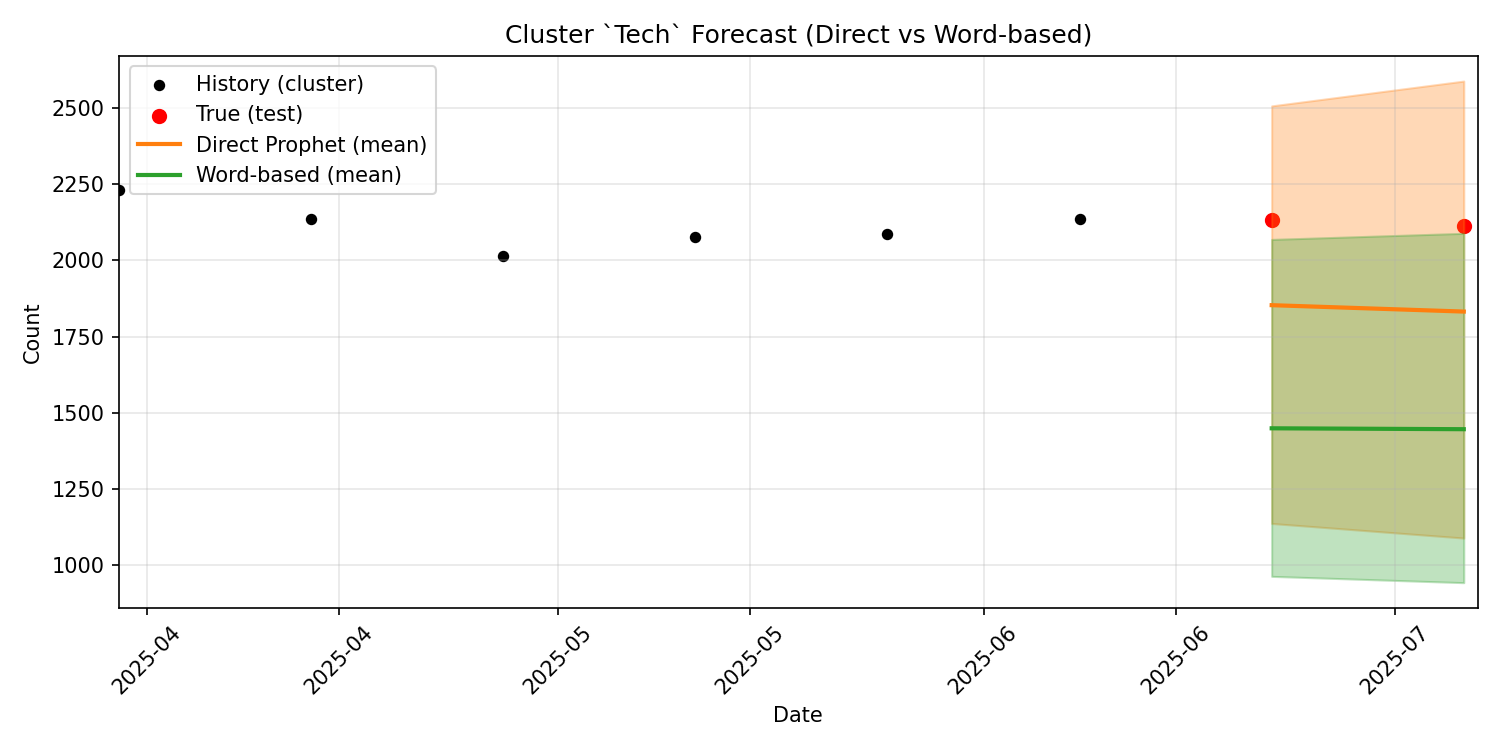

In [391]:
import matplotlib.dates as mdates

# -------------------------------
# H2: Word-level vs Direct Prediction (почти без изменений, но mean берём из forecast)
# -------------------------------

# 1) Direct Prophet (MCMC → эмпирический интервал)
direct_samples = {}
direct_means   = {}
for i, cluster in enumerate(clusters):
    history_cluster = pd.DataFrame({
        'ds': dates[:-test_size],
        'y':  y_train[:, i]
    })
    model_dir = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.95,         # формально неважно для predictive_samples
        changepoint_prior_scale=0.5,
        mcmc_samples=300
    )
    model_dir.fit(history_cluster)

    future = model_dir.make_future_dataframe(periods=test_size, freq='2W')
    forecast_dir = model_dir.predict(future)

    # 1a) Точечный (детерминированный) forecast['yhat'] для test
    direct_means[cluster] = forecast_dir.loc[
        forecast_dir['ds'].isin(dates[-test_size:]), 'yhat'
    ].values

    # 1b) Семплы для эмпирического интервала
    ps_dir = model_dir.predictive_samples(future)
    direct_samples[cluster] = ps_dir['yhat'][:, -test_size:]  
    # shape = (n_sims, test_size)

# 2) Word-based Prophet:
#    - точечный sum(map_yhat) по словам
#    - эмпирический семпл-интервал: sum семплов по каждому слову

word_samples = {}
word_means   = {}
for i, cluster in enumerate(clusters):
    idxs = [
        j for j, w in enumerate(selected_vocab)
        if df[df['Topic'] == w]['Cluster'].iloc[0] == cluster
    ]
    if not idxs:
        continue

    per_word_samps = []
    per_word_mean  = []

    for j in idxs:
        w = selected_vocab[j]
        history_word = pd.DataFrame({
            'ds': dates[:-test_size],
            'y':  X_train_selected_orig[:, j]
        })
        model_w = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
            changepoint_prior_scale=0.5,
            mcmc_samples=300
        )
        model_w.fit(history_word)

        future_w = model_w.make_future_dataframe(periods=test_size, freq='2W')
        forecast_w = model_w.predict(future_w)

        # 2a) Точечный прогноз (MAP) для слова j
        mean_w = forecast_w.loc[
            forecast_w['ds'].isin(dates[-test_size:]), 'yhat'
        ].values
        per_word_mean.append(mean_w)

        # 2b) Семплы (predictive_samples) для слова j
        ps_w = model_w.predictive_samples(future_w)
        per_word_samps.append(ps_w['yhat'][:, -test_size:])  
        # shape (n_sims, test_size)

    # 2a) Суммарный MAP-прогноз для Word-based
    sum_mean = np.sum(np.stack(per_word_mean, axis=0), axis=0)
    word_means[cluster] = sum_mean  # shape = (test_size,)

    # 2b) Суммарные семплы: складываем семплы всех слов
    stacked = np.stack(per_word_samps, axis=0)   # shape = (num_words, n_sims, test_size)
    sum_samps = np.sum(stacked, axis=0)         # shape = (n_sims, test_size)
    word_samples[cluster] = sum_samps

# 3) Рисуем графики (игнорируя останки остального кода, оставим только блок построения)

last_history = 6  # последние 6 точек истории (12 недель)

for i, cluster in enumerate(clusters):
    dates_all = pd.to_datetime(dates)

    start_idx = -(test_size + last_history)
    if abs(start_idx) > len(dates_all):
        start_idx = 0

    hist_dates = dates_all[start_idx:-test_size]
    hist_vals  = cluster_matrix[cluster].values[start_idx:-test_size]
    future_dates = dates_all[-test_size:]

    # 3.1) EMPIrические квантильные границы для Direct
    samp_dir = direct_samples[cluster]    # shape = (n_sims, test_size)
    lo_dir   = np.percentile(samp_dir,  2.5, axis=0)
    hi_dir   = np.percentile(samp_dir, 97.5, axis=0)
    mean_dir = direct_means[cluster]     # MAP-mean из forecast['yhat']

    # 3.2) EMPIrические квантильные границы для Word-based (если есть)
    samp_word  = word_samples.get(cluster, None)
    if samp_word is not None:
        lo_word   = np.percentile(samp_word,  2.5, axis=0)
        hi_word   = np.percentile(samp_word, 97.5, axis=0)
        mean_word = word_means[cluster]     # MAP-mean sum из forecast['yhat']

    true_vals = y_test[:, i]

    fig, ax = plt.subplots(figsize=(10, 5))

    # — История (последние last_history) чёрные точки
    ax.scatter(hist_dates, hist_vals,
               color='black', s=20, label='History (cluster)')

    # — Истинные тестовые точки красные
    ax.scatter(future_dates, true_vals,
               color='red', s=40, marker='o', label='True (test)')

    # — Direct Prophet (MAP-mean + эмпирический интервал)
    ax.plot(future_dates, mean_dir,
            color='tab:orange', lw=2, label='Direct Prophet (mean)')
    ax.fill_between(future_dates,
                    lo_dir, hi_dir,
                    color='tab:orange', alpha=0.3)

    # — Word-based Prophet (MAP-mean + эмпирический интервал)
    if samp_word is not None:
        ax.plot(future_dates, mean_word,
                color='tab:green', lw=2, label='Word-based (mean)')
        ax.fill_between(future_dates,
                        lo_word, hi_word,
                        color='tab:green', alpha=0.3)

    ax.set_title(f"Cluster `{cluster}` Forecast (Direct vs Word-based)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

    xmin = hist_dates.min()
    xmax = future_dates.max()
    ax.set_xlim(xmin, xmax + pd.Timedelta(days=1))

    plt.tight_layout()
    out_name = f"cluster_{cluster}_forecast_with_intervals.png"
    plt.savefig(out_name, dpi=150)
    plt.close()
    print(f"Saved plot → {out_name}")


11:38:47 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)
chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:38:49 - cmdstanpy - INFO - CmdStan done processing.
11:38:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:38:49 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 31 iterations at max treedepth (20.7%)
	Chain 2 had 10 iterations at max treedepth (6.7%)
	Chain 3 had 68 iterations at max treedepth (45.3%)
	Chain 4 had 30 iterations at max treedepth (20.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


11:38:49 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)
chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)

chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:38:51 - cmdstanpy - INFO - CmdStan done processing.
11:38:51 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:38:51 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 5 divergent transitions (3.3%)
	Chain 1 had 113 iterations at max treedepth (75.3%)
	Chain 2 had 133 iterations at max treedepth (88.7%)
	Chain 3 had 1 divergent transitions (0.7%)
	Chain 3 had 105 iterations at max treedepth (70.0%)
	Chain 4 had 2 divergent transitions (1.3%)
	Chain 4 had 136 iterations at max treedepth (90.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


11:38:52 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)
chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     

...

11:39:21 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)


chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)


chain 1 |██████████| 00:01 Iteration: 250 / 300 [ 83%]  (Sampling)
chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:39:23 - cmdstanpy - INFO - CmdStan done processing.
11:39:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:39:23 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 7 divergent transitions (4.7%)
	Chain 1 had 141 iterations at max treedepth (94.0%)
	Chain 2 had 1 divergent transitions (0.7%)
	Chain 2

11:39:24 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |████      | 00:00 Iteration:   1 / 300 [  0%]  (Warmup)

chain 1 |██████    | 00:00 Iteration: 100 / 300 [ 33%]  (Warmup)


chain 1 |████████  | 00:01 Iteration: 151 / 300 [ 50%]  (Sampling)



chain 1 |██████████| 00:01 Sampling completed                     
chain 2 |██████████| 00:01 Sampling completed                     
chain 3 |██████████| 00:01 Sampling completed                     
chain 4 |██████████| 00:01 Sampling completed                     


11:39:25 - cmdstanpy - INFO - CmdStan done processing.
11:39:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!
11:39:25 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 4 divergent transitions (2.7%)
	Chain 1 had 146 iterations at max treedepth (97.3%)
	Chain 2 had 150 iterations at max treedepth (100.0%)
	Chain 3 had 8 divergent transitions (5.3%)
	Chain 3 had 142 iterations at max treedepth (94.7%)
	Chain 4 had 5 divergent transitions (3.3%)
	Chain 4 had 145 iterations at max treedepth (96.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



Saved plot → cluster_Sports_forecast_with_intervals.png
Saved plot → cluster_Music_forecast_with_intervals.png
Saved plot → cluster_Tech_forecast_with_intervals.png
